Fetching NBA team data for 2024-25 (Advanced stats)...
Data retrieved successfully.
           TEAM_NAME  W_PCT  OFF_RATING  DEF_RATING  NET_RATING    PACE  TS_PCT  EFG_PCT  AST_RATIO  REB_PCT  TM_TOV_PCT    PIE
0      Atlanta Hawks  0.488       113.7       114.8        -1.1  103.41   0.579    0.546       19.9    0.503       0.149  0.498
1     Boston Celtics  0.744       119.5       110.1         9.4   96.59   0.591    0.561       19.0    0.506       0.122  0.542
2      Brooklyn Nets  0.317       108.1       115.4        -7.3   96.73   0.552    0.516       18.4    0.487       0.156  0.452
3  Charlotte Hornets  0.232       106.7       115.7        -9.1   98.22   0.537    0.503       17.5    0.500       0.157  0.450
4      Chicago Bulls  0.476       113.2       114.8        -1.6  103.61   0.585    0.553       19.9    0.496       0.141  0.495

Explained Variance Ratio (Each PC):
[5.77476588e-01 1.77910851e-01 1.13920431e-01 6.00884038e-02
 3.93717700e-02 2.59407345e-02 4.10775312e-03 8.91

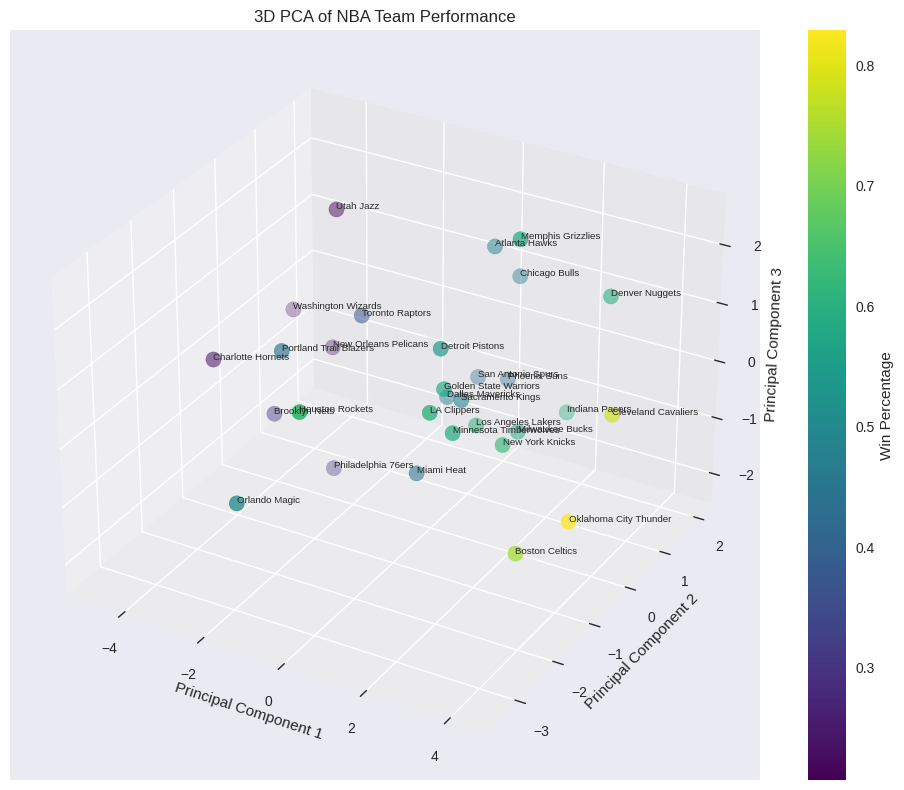


PCA Loadings:
                 PC1       PC2       PC3
PIE         0.406347 -0.135447  0.019653
OFF_RATING  0.401421  0.030843  0.048120
NET_RATING  0.391627 -0.233775  0.033916
EFG_PCT     0.372186  0.269470 -0.027373
TS_PCT      0.367031  0.262595 -0.041217
AST_RATIO   0.231979  0.476104  0.018597
REB_PCT     0.171455 -0.332497  0.673995
PACE        0.030310  0.452877  0.539385
DEF_RATING -0.262091  0.492088 -0.005658
TM_TOV_PCT -0.307107  0.002134  0.498113


In [15]:
!pip install nba_api
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import leaguedashteamstats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
from mpl_toolkits.mplot3d import Axes3D 
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

def fetch_team_data(season='2024-25'):
    print(f"Fetching NBA team data for {season} (Advanced stats)...")
    
    team_stats = leaguedashteamstats.LeagueDashTeamStats(
        season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense='Advanced'
    )
    
    df = team_stats.get_data_frames()[0]
    print("Data retrieved successfully.")
    
    return df

def prepare_data(df):

    features = [
        'OFF_RATING',
        'DEF_RATING',
        'NET_RATING',
        'PACE',
        'TS_PCT',
        'EFG_PCT',
        'AST_RATIO',
        'REB_PCT',
        'TM_TOV_PCT',
        'PIE'
    ]

    df = df[['TEAM_NAME', 'W_PCT'] + features]
    df = df.dropna()

    return df, features

def run_pca(df, features):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

    # Fit PCA with ALL components
    pca_full = PCA()
    X_pca_full = pca_full.fit_transform(X_scaled)

    explained_variance = pca_full.explained_variance_ratio_
    eigenvalues = pca_full.explained_variance_
    cumulative_variance = np.cumsum(explained_variance)

    print("\nExplained Variance Ratio (Each PC):")
    print(explained_variance)

    print("\nCumulative Explained Variance:")
    print(cumulative_variance)

    var_2d = cumulative_variance[1] * 100
    print(f"\n% Information retained in 2D (PC1 + PC2): {var_2d:.2f}%")
    print()

    var_3d = cumulative_variance[2] * 100
    print(f"% Information retained in 3D (PC1 + PC2 + PC3): {var_3d:.2f}%")
    print()

    dims_95 = np.argmax(cumulative_variance >= 0.95) + 1
    print(f"\nNumber of dimensions needed to retain ≥95% variance: {dims_95}")
    print()

    print("\nTop 3 Eigenvalues:")
    print(eigenvalues[:3])
    print()

    pca_3 = PCA(n_components=3)
    X_pca_3 = pca_3.fit_transform(X_scaled)

    pca_df = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])
    pca_df['TEAM_NAME'] = df['TEAM_NAME'].values
    pca_df['W_PCT'] = df['W_PCT'].values

    return pca_full, pca_df

def plot_pca(pca_df):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        pca_df['PC1'],
        pca_df['PC2'],
        pca_df['PC3'],
        c=pca_df['W_PCT'],
        cmap='viridis',
        s=120
    )

    # Add team labels
    for i, team in enumerate(pca_df['TEAM_NAME']):
        ax.text(
            pca_df['PC1'][i],
            pca_df['PC2'][i],
            pca_df['PC3'][i],
            team,
            fontsize=7
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_zlabel("Principal Component 3")
    ax.set_title("3D PCA of NBA Team Performance")

    fig.colorbar(scatter, ax=ax, label="Win Percentage")

    plt.tight_layout()
    plt.show()

def show_loadings(pca, features):
    loadings = pd.DataFrame(
        pca.components_[:3].T,
        columns=['PC1', 'PC2', 'PC3'],
        index=features
    )
    
    print("\nPCA Loadings:")
    print(loadings.sort_values(by='PC1', ascending=False))

if __name__ == "__main__":
    
    df_raw = fetch_team_data(season='2024-25')
    df_clean, features = prepare_data(df_raw)

    print(df_clean.head().to_string())
    
    pca_model, pca_results = run_pca(df_clean, features)
    plot_pca(pca_results)
    show_loadings(pca_model, features)